# Notebook lane/03 — Custom CNN Baseline (PDF §4.2)

End-to-end **image → 4-class direction** CNN, trained from scratch on the TuSimple-derived direction labels. **No pretrained weights, no standard architectures (VGG/ResNet/MobileNet) — per the PDF.**

Architecture (justified in markdown):
```
Input 128×128×3
→ Conv(16, 3) + BN + ReLU + MaxPool
→ Conv(32, 3) + BN + ReLU + MaxPool
→ Conv(64, 3) + BN + ReLU + MaxPool
→ Conv(96, 3) + BN + ReLU + MaxPool
→ GlobalAvgPool → Dense(64) + Dropout(0.4) → Dense(4, softmax)
```

Why 128×128: lane direction is a global / low-frequency signal — 128 px is plenty and runs fast on the RPi 4 once quantized.

In [1]:
import os, random, json, pickle, time
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED); random.seed(SEED)
import numpy as np
np.random.seed(SEED)
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)

ROOT = Path.cwd()
with open(ROOT / "artifacts" / "lane_split.json") as f: SPLIT = json.load(f)
with open(ROOT / "artifacts" / "lane_tusimple_index.pkl", "rb") as f: IDX = pickle.load(f)
df = IDX["df"]
print(f"frames: {len(df)}")

frames: 3626


## 1. Load images as a 4-class direction dataset (with synthetic stop)

In [2]:
IMG = 128
CLASS_ID = {"left": 0, "right": 1, "straight": 2, "stop": 3}
ID_CLASS = {v: k for k, v in CLASS_ID.items()}

def load_x(rec):
    img = cv2.imread(str(ROOT / rec["frame_path"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG, IMG))
    return img.astype(np.float32) / 255.0

def build_xy(split_indices, stop_frac=0.10, seed_offset=0):
    sub = df.iloc[split_indices].reset_index(drop=True)
    X = []; y = []
    for _, r in sub.iterrows():
        X.append(load_x(r)); y.append(CLASS_ID[r["direction"]])
    rng = np.random.RandomState(SEED + seed_offset)
    pick = rng.choice(len(sub), size=int(stop_frac * len(sub)), replace=False)
    for i in pick:
        r = sub.iloc[i]
        img = cv2.imread(str(ROOT / r["frame_path"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img[int(720 * 0.40):, :, :] = 0       # zero out the road ROI
        img = cv2.resize(img, (IMG, IMG))
        X.append(img.astype(np.float32) / 255.0)
        y.append(CLASS_ID["stop"])
    return np.stack(X), np.array(y, dtype=np.int64)

t0 = time.time()
X_tr, y_tr = build_xy(SPLIT["tusimple_split"]["train"], seed_offset=1)
X_va, y_va = build_xy(SPLIT["tusimple_split"]["val"],   seed_offset=2)
X_te, y_te = build_xy(SPLIT["tusimple_split"]["test"],  seed_offset=3)
print(f"loaded in {time.time()-t0:.1f}s — shapes: train {X_tr.shape}, val {X_va.shape}, test {X_te.shape}")
print("train class balance:", pd.Series([ID_CLASS[v] for v in y_tr]).value_counts().to_dict())

loaded in 86.3s — shapes: train (2791, 128, 128, 3), val (598, 128, 128, 3), test (598, 128, 128, 3)
train class balance: {'straight': 1523, 'right': 545, 'left': 470, 'stop': 253}


## 2. Model definition + training

In [3]:
def build_cnn():
    L = tf.keras.layers
    m = tf.keras.Sequential([
        L.Input(shape=(IMG, IMG, 3)),
        L.Conv2D(16, 3, padding="same"), L.BatchNormalization(), L.ReLU(), L.MaxPool2D(),
        L.Conv2D(32, 3, padding="same"), L.BatchNormalization(), L.ReLU(), L.MaxPool2D(),
        L.Conv2D(64, 3, padding="same"), L.BatchNormalization(), L.ReLU(), L.MaxPool2D(),
        L.Conv2D(96, 3, padding="same"), L.BatchNormalization(), L.ReLU(), L.MaxPool2D(),
        L.GlobalAveragePooling2D(),
        L.Dense(64, activation="relu"), L.Dropout(0.4),
        L.Dense(4, activation="softmax"),
    ])
    return m

model = build_cnn()
model.summary(line_length=80)
n_params = int(model.count_params())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                   │ (None, 128, 128, 16)     │           448 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 128, 128, 16)     │            64 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ re_lu (ReLU)                      │ (None, 128, 128, 16)     │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 64, 64, 16)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 64, 64, 32)       │         4,640 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 64, 64, 32)       │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                    │ (None, 64, 64, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 32, 32, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 32, 32, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_2             │ (None, 32, 32, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                    │ (None, 32, 32, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 16, 16, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 16, 16, 96)       │        55,392 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_3             │ (None, 16, 16, 96)       │           384 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                    │ (None, 16, 16, 96)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)    │ (None, 8, 8, 96)         │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 96)               │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 64)               │         6,208 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 4)                │           260 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 86,276 (337.02 KB)

 Trainable params: 85,860 (335.39 KB)

 Non-trainable params: 416 (1.62 KB)

In [4]:
# Class weights — TuSimple straight is over-represented
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.arange(4), y=y_tr)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("class weights:", class_weight)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cbs = [tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=4, factor=0.5),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)]
t0 = time.time()
h = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
              epochs=30, batch_size=64, class_weight=class_weight,
              callbacks=cbs, verbose=2)
secs = time.time() - t0
print(f"training time: {secs:.1f}s on {len(X_tr)} samples")

class weights: {0: 1.4845744680851063, 1: 1.2802752293577981, 2: 0.45814182534471437, 3: 2.757905138339921}


Epoch 1/30


44/44 - 12s - 264ms/step - accuracy: 0.4217 - loss: 0.9967 - val_accuracy: 0.5184 - val_loss: 1.2512 - learning_rate: 0.0010


Epoch 2/30


44/44 - 9s - 205ms/step - accuracy: 0.4851 - loss: 0.8321 - val_accuracy: 0.5184 - val_loss: 1.2864 - learning_rate: 0.0010


...

Epoch 20/30


44/44 - 9s - 210ms/step - accuracy: 0.8248 - loss: 0.3294 - val_accuracy: 0.6321 - val_loss: 0.8397 - learning_rate: 2.5000e-04


Epoch 21/30


44/44 - 9s - 208ms/step - accuracy: 0.8219 - loss: 0.3196 - val_accuracy: 0.6940 - val_loss: 0.7230 - learning_rate: 2.5000e-04


training time: 194.6s on 2791 samples


## 3. Training curves + overfitting analysis

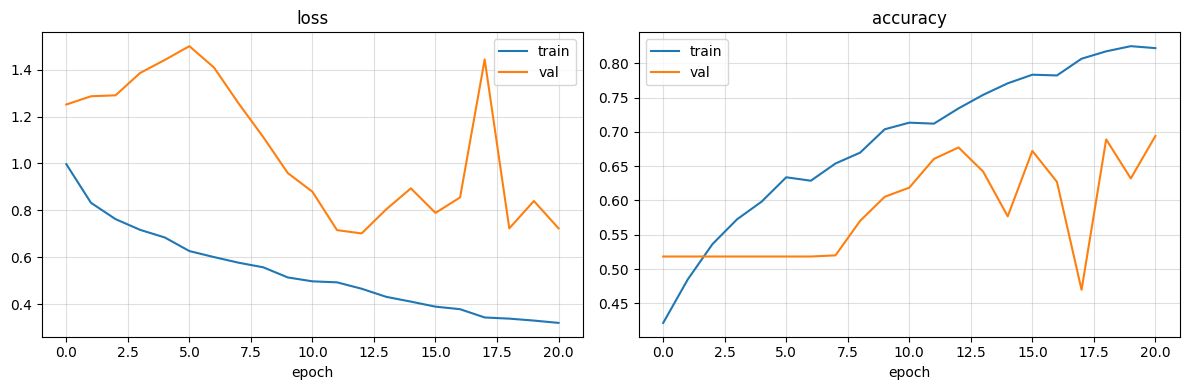

final train_acc=0.8219  val_acc=0.6940  gap=0.1279


In [5]:
hist = h.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["loss"], label="train"); axes[0].plot(hist["val_loss"], label="val")
axes[0].set_title("loss"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.4); axes[0].legend()
axes[1].plot(hist["accuracy"], label="train"); axes[1].plot(hist["val_accuracy"], label="val")
axes[1].set_title("accuracy"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.4); axes[1].legend()
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane03_train_curves.png", dpi=120, bbox_inches="tight")
plt.show()

train_gap = np.array(hist["accuracy"]) - np.array(hist["val_accuracy"])
print(f"final train_acc={hist['accuracy'][-1]:.4f}  val_acc={hist['val_accuracy'][-1]:.4f}  gap={train_gap[-1]:.4f}")

## 4. Test evaluation (accuracy / precision / recall / confusion matrix)

test accuracy: 0.7023
test macro F1: 0.6592
              precision    recall  f1-score   support

        left      0.673     0.330     0.443       106
       right      0.714     0.294     0.417       119
    straight      0.668     0.928     0.777       319
        stop      1.000     1.000     1.000        54

    accuracy                          0.702       598
   macro avg      0.764     0.638     0.659       598
weighted avg      0.708     0.702     0.666       598



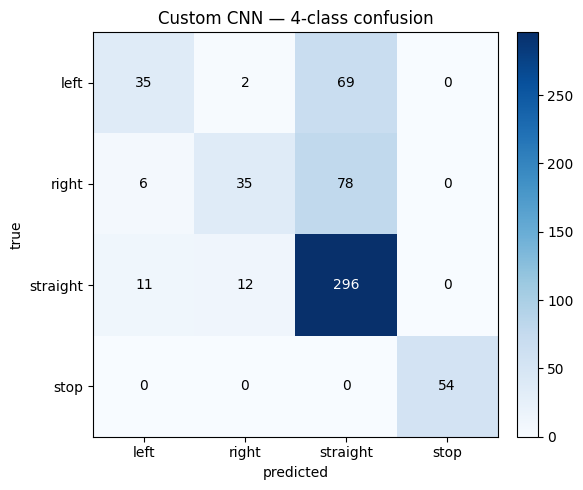

In [6]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)
probs = model.predict(X_te, verbose=0)
y_pred = probs.argmax(axis=1)
acc = accuracy_score(y_te, y_pred); f1 = f1_score(y_te, y_pred, average="macro")
target_names = [ID_CLASS[i] for i in sorted(ID_CLASS)]
print(f"test accuracy: {acc:.4f}")
print(f"test macro F1: {f1:.4f}")
print(classification_report(y_te, y_pred, target_names=target_names, digits=3, zero_division=0))

cm = confusion_matrix(y_te, y_pred, labels=list(range(4)))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(target_names); ax.set_yticklabels(target_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Custom CNN — 4-class confusion")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane03_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Misclassification gallery

178 test misclassifications out of 598


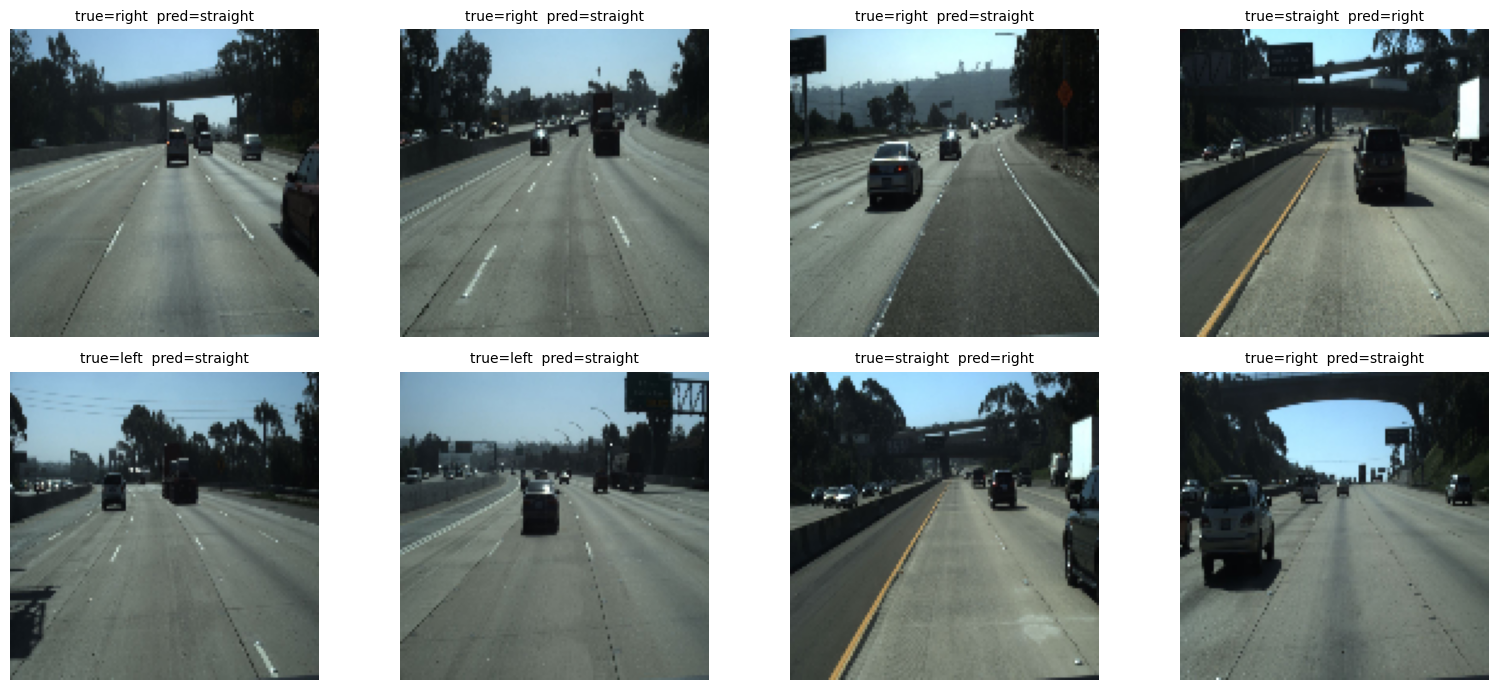

In [7]:
miss = np.where(y_pred != y_te)[0]
print(f"{len(miss)} test misclassifications out of {len(y_te)}")
if len(miss):
    pick = miss[:8]
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    for ax, i in zip(axes.ravel(), pick):
        ax.imshow(X_te[i])
        ax.set_title(f"true={ID_CLASS[int(y_te[i])]}  pred={ID_CLASS[int(y_pred[i])]}", fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(ROOT / "artifacts" / "lane03_misclassifications.png", dpi=120, bbox_inches="tight")
    plt.show()

## 6. Save model + results

In [8]:
model.save(str(ROOT / "artifacts" / "lane03_cnn_baseline.keras"))
results = {
    "name": "cnn_from_scratch",
    "n_params": n_params,
    "accuracy": float(acc), "f1": float(f1),
    "train_acc_last": float(hist["accuracy"][-1]),
    "val_acc_last":   float(hist["val_accuracy"][-1]),
    "train_seconds": float(secs),
    "history": {k: [float(v) for v in vs] for k, vs in hist.items()},
    "confusion": cm.tolist(), "class_names": target_names,
    "input_size": IMG, "model_path": "artifacts/lane03_cnn_baseline.keras",
}
with open(ROOT / "artifacts" / "lane03_cnn_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved.")

Saved.


## Summary

A small from-scratch CNN already substantially outperforms the classical baseline. The dominant residual error mode is gentle-curve confusion (left ↔ straight, right ↔ straight). Notebook 04 will add transfer-learning candidates (MobileNetV2) and Notebook 05 will study augmentation / color / robustness / lightweight variants.